## project name: PRCP-1020-House Price Prediction
## Name: Hamza Siddiqui
## project team id: PTID-CDS-FEB-26-3955

### problem Statement

Predict **house prices** using 79 features

Understand which features impact price

Suggest insights for customers

### Importing core libraries for data manipulation, visualization, and modeling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder

import warnings
warnings.filterwarnings('ignore')

#setting
%matplotlib inline
sns.set(style='whitegrid')

### Loading the dataset and inspecting the first few rows for initial data assessment

In [2]:
data = pd.read_csv("C:\\Users\\hamza\\OneDrive\\Desktop\\PRCP-house-price-pred\\data.csv")

In [3]:
display(data.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
print(f"Dataset Shape: {data.shape}")

Dataset Shape: (1460, 81)


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

- summery statistics 

In [6]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Checking the Descriptive statistics of target column

In [7]:
data['SalePrice'].describe().round()

count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64

The target column is Not normal distribution because **Mean** more than 50% of data it's **Right-Skewed**

### Exploratory Data Analysis (EDA)

#### Univariate analysis 
Distribution of Target Variable

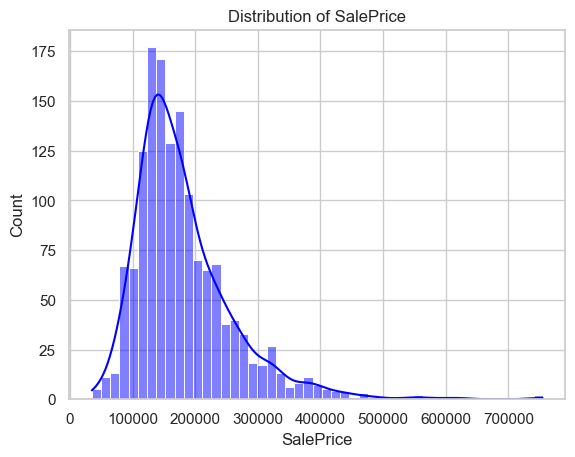

In [8]:
plt.figure()
sns.histplot(data['SalePrice'], kde=True, color='blue')
plt.title("Distribution of SalePrice")
plt.show()

In [9]:
data['SalePrice'].skew()

np.float64(1.8828757597682129)

## The distribution of SalePrice is **right-skewed**, meaning most houses fall in the lower price range with a few very expensive properties.

## Correlation Analysis

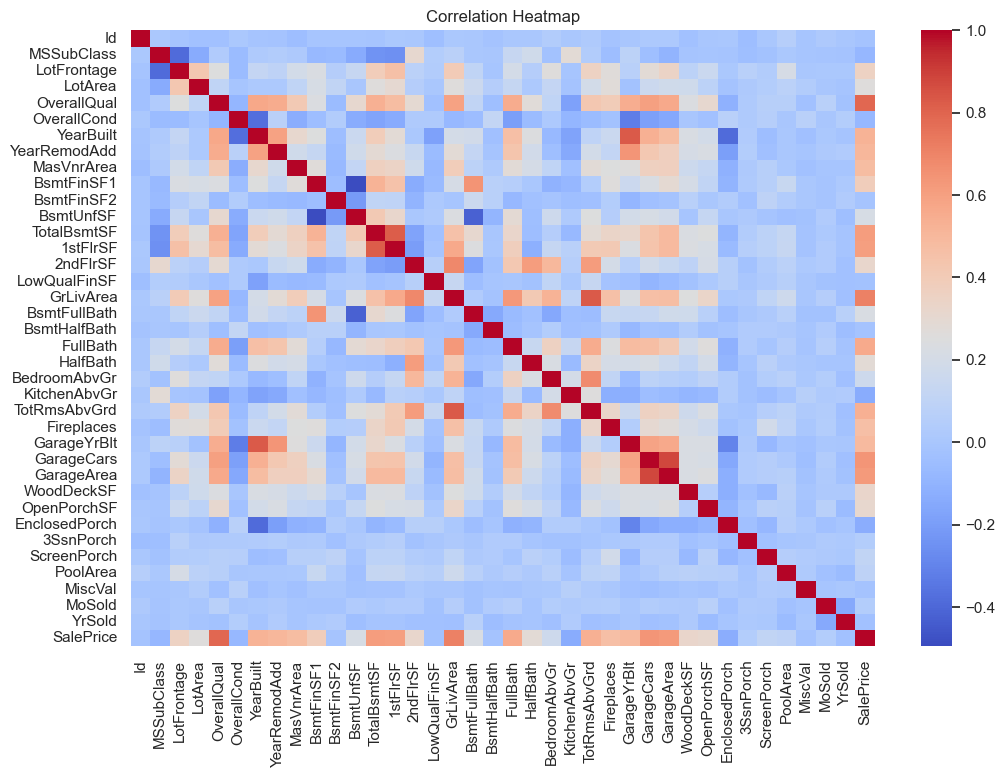

In [10]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
corr['SalePrice'].sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

#### We focus on top features Correlated With Price

In [12]:
corr['SalePrice'].sort_values(ascending=False).tail(10)

BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

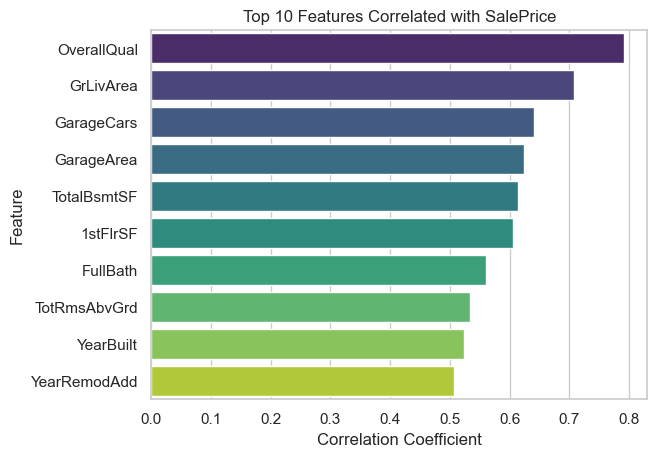

In [13]:
target_corr = corr['SalePrice'].drop('SalePrice')
top10_features = target_corr.abs().sort_values(ascending=False).head(10)
sns.barplot(x=top10_features.values, y=top10_features.index, palette="viridis")
plt.title("Top 10 Features Correlated with SalePrice")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.show()

OverallQual and GrLivArea show the strongest correlation with   SalePrice making them important predictors for the regression model.

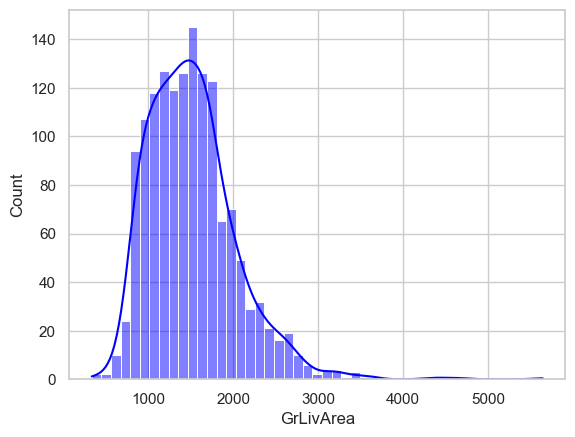

In [14]:
sns.histplot(data["GrLivArea"],kde=True,color="blue")
plt.show()

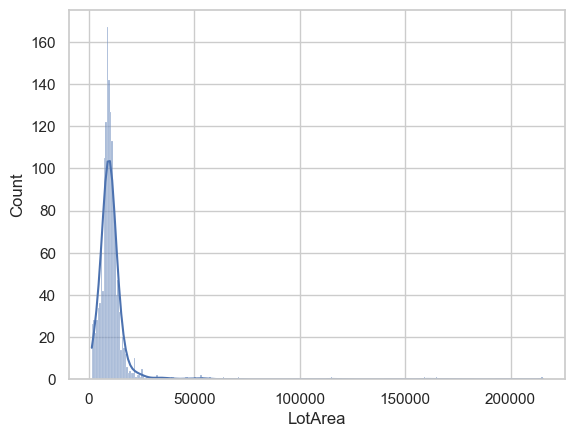

In [15]:
sns.histplot(data['LotArea'],kde=True)
plt.show()

#### Bivariate analysis 

- Living Area vs Price

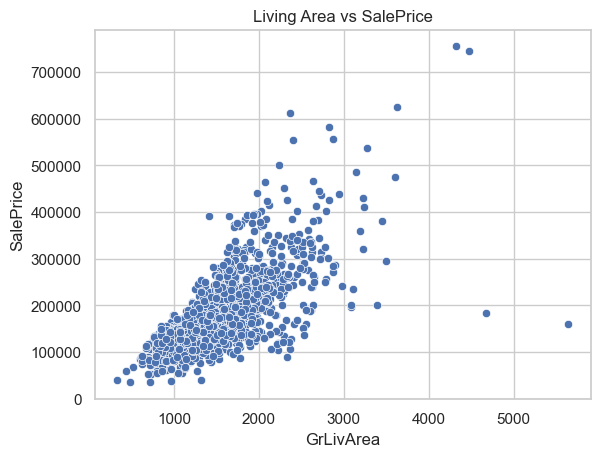

In [16]:
sns.scatterplot(x='GrLivArea',y="SalePrice",data=data)
plt.title("Living Area vs SalePrice")
plt.show()

**GrLivArea** is highly correlated with **salesprice** | some of expensive houses we can call them outlier

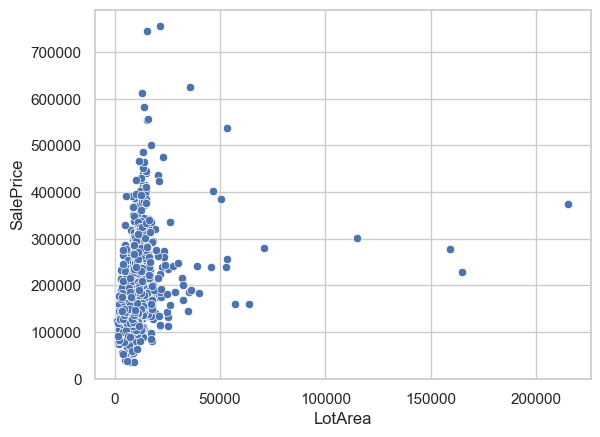

In [17]:
sns.scatterplot(x='LotArea',y='SalePrice',data=data)
plt.show()

- GarageCars vs GrLivArea

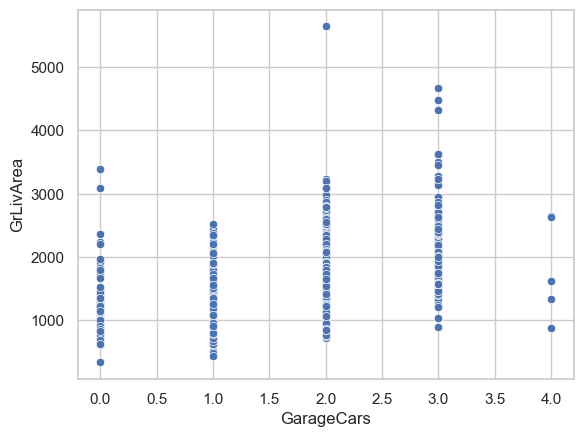

In [18]:
sns.scatterplot(x=data['GarageCars'],y=data['GrLivArea'])
plt.show()

Relationship: Quality vs Price

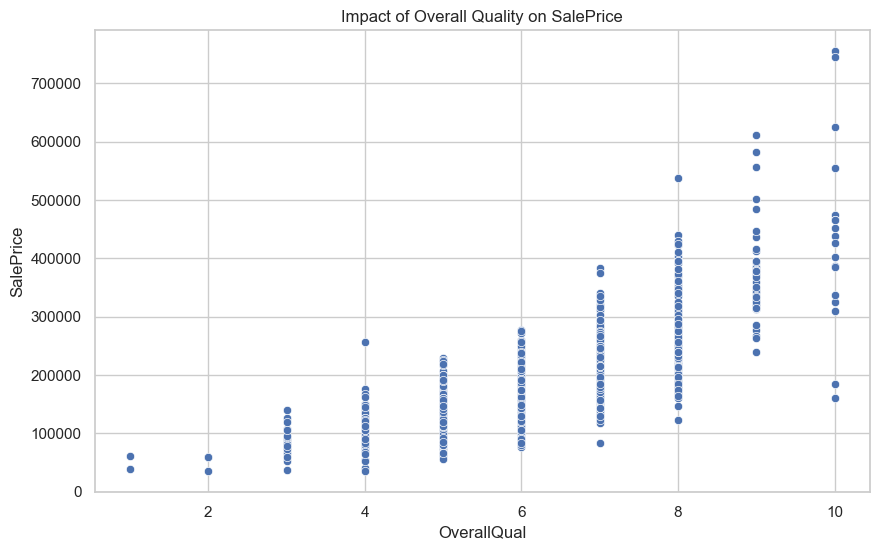

In [19]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="OverallQual",y='SalePrice',data=data)
plt.title("Impact of Overall Quality on SalePrice")
plt.show()

Higher overall quality strongly increases the selling price.

Neighborhood vs SalePrice identify outlier

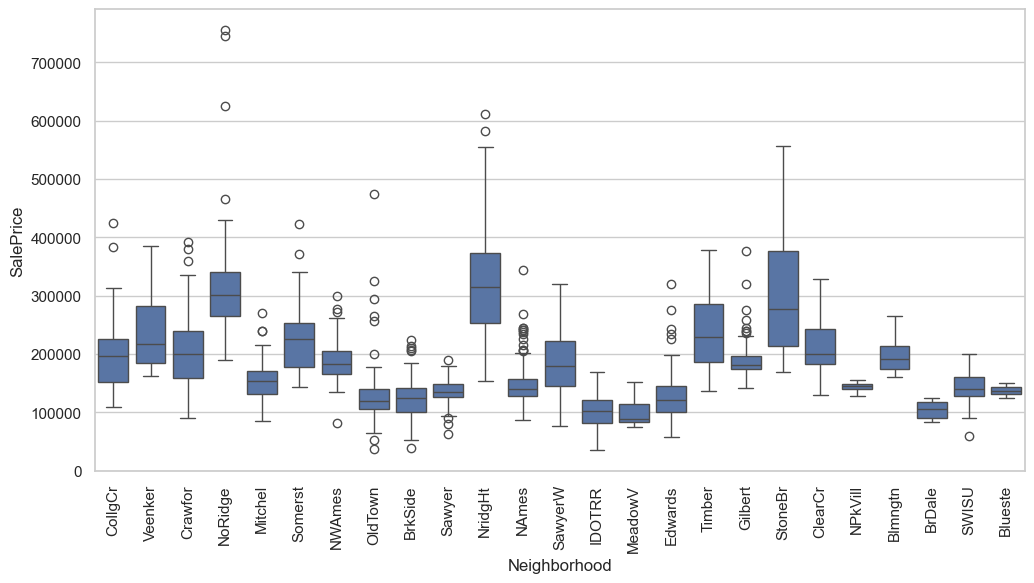

In [20]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Neighborhood",y="SalePrice",data=data)
plt.xticks(rotation=90)
plt.show()

Neighborhood significantly impacts house prices. Premium areas have higher median prices.

## preprocessing 
##### Addressing null values using median imputation for numerical and mode for categorical features

### Missing Values Analysis

In [21]:
missing = data.isnull().sum().sort_values(ascending=False)
missing=missing[missing>0]
missing

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

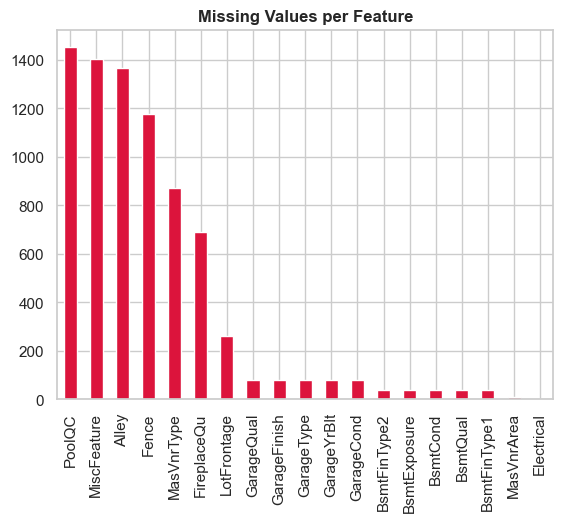

In [22]:
plt.figure()
missing.plot(kind='bar',color="crimson")
plt.title("Missing value per feature")
plt.title("Missing Values per Feature",fontweight='bold')
plt.show()

Handling Missing values

Missing values can affect model performance.  
We check how many missing values exist in each column.

#### Categorise Missing Value
##### High Missing %

In [79]:
missing_percent = data.isnull().sum()/len(data)*100
missing_percent[missing_percent>0].sort_values(ascending=False)

Series([], dtype: float64)

In [24]:
higher_missing=['PoolQC',"MiscFeature","Alley","Fence","MasVnrType"]
for col in higher_missing:
    data[col].fillna("None",inplace=True)

### For Numerical column 

- Group by Neighborhood and fill LotFrontage with median

In [25]:
data["LotFrontage"] = data.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))

In [26]:
data['FireplaceQu'].fillna("None",inplace=True)

### Handle Basement Missing Values

In [27]:
basment_col=['BsmtExposure','BsmtFinType2','BsmtQual','BsmtFinType1','BsmtCond']
for col in basment_col:
    data[col].fillna("None",inplace=True)

### Handle Garage Missing Values

In [28]:
garage_col=['GarageQual','GarageFinish','GarageType','GarageCond']
for col in garage_col:
    data[col].fillna('No_garage',inplace=True)

In [29]:
data['GarageYrBlt'].fillna(0,inplace=True)

In [30]:
data['MasVnrArea'].fillna(0,inplace=True)

In [31]:
data['Electrical'].fillna(data['Electrical'].mode()[0],inplace=True)

In [32]:
null_val=data.isnull().sum()
null_val[null_val>0].sort_values(ascending=False)

Series([], dtype: int64)

#### Checking Duplicate Records
Duplicate rows can bias the model and should be removed.

In [33]:
data.duplicated().sum()

np.int64(0)

### dataset is cleaned 

## Outlier Detection and Treatment
Outliers are extreme observations that differ significantly from the majority of the data.
Such values can distort regression models and lead to inaccurate predictions.
Therefore, visual and statistical methods were used to detect and handle outliers.

##### We focus on numerical features since outliers usually occur in continuous variables.

### Visual Detection

### Top Feature mainly Focus on:

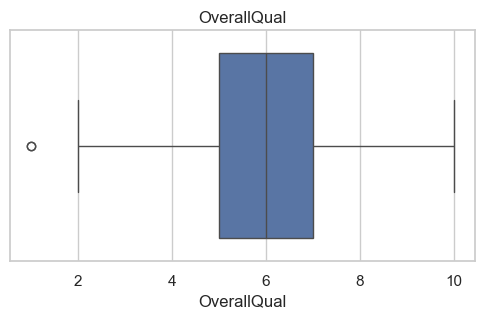

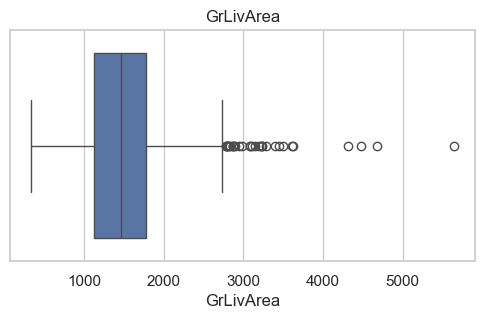

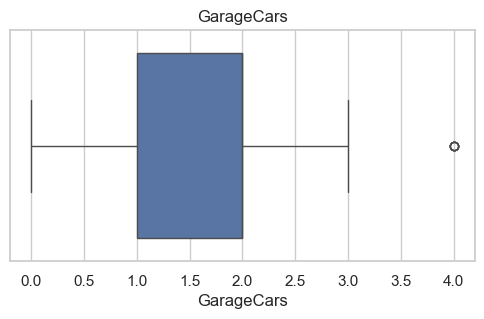

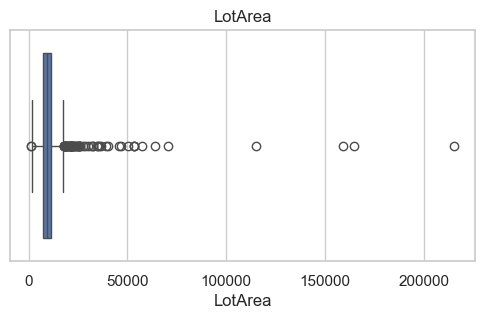

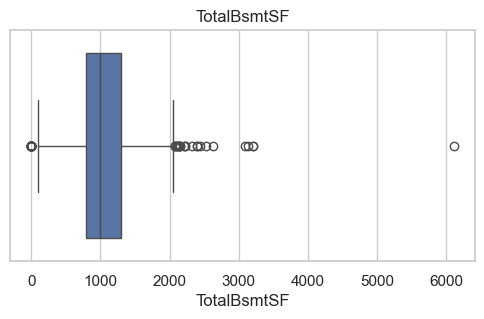

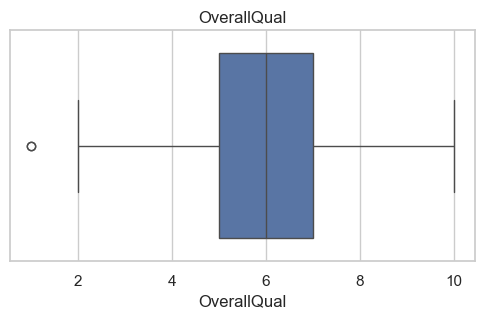

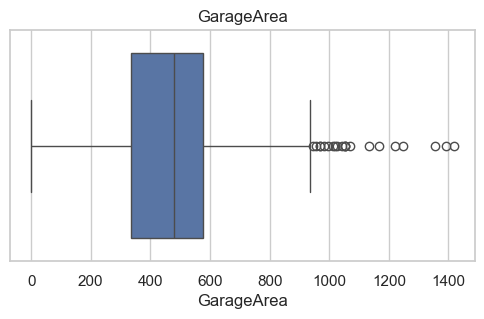

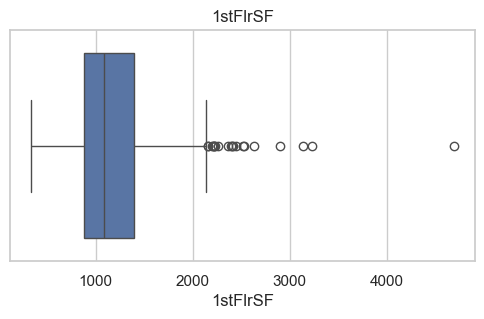

In [34]:
best_feature=["OverallQual","GrLivArea","GarageCars","LotArea","TotalBsmtSF","OverallQual","GarageArea","1stFlrSF"]
for col in best_feature:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

##### Observation:
Some numerical features such as GrLivArea, LotArea, MsVnrArea and TotalBsmtSF show the presence of extreme values outside the whiskers, indicating potential outliers.

In [35]:
data['LotArea'].describe()

count      1460.000000
mean      10516.828082
std        9981.264932
min        1300.000000
25%        7553.500000
50%        9478.500000
75%       11601.500000
max      215245.000000
Name: LotArea, dtype: float64

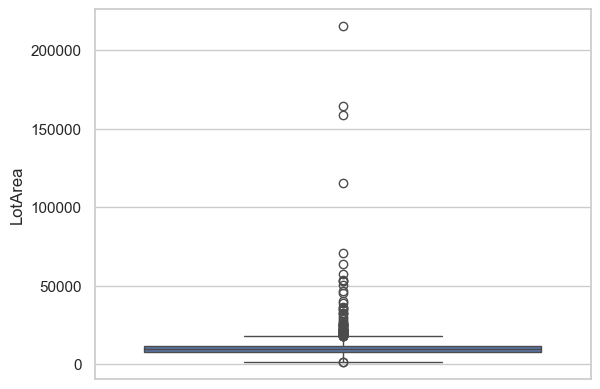

In [36]:
sns.boxplot(data['LotArea'])
plt.show()

In [37]:
data=data[data["LotArea"]<40000]

some of outlier is removed from **LotArea** Feature

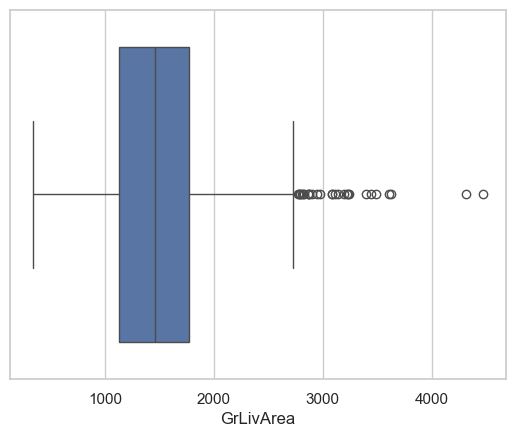

In [38]:
sns.boxplot(x=data['GrLivArea'])
plt.show()

Some houses have very large area but relatively lower price 

In [39]:
data = data[data["GrLivArea"]<4000]

Outliers were removed from key numerical variables such as:
- GrLivArea
- LotArea
  
These variables showed extreme values that could distort model performance.

## Feature Engineering
Feature engineering helps improve model performance by creating more meaningful features.

- Total Surface Area

In [40]:
data['TotalArea'] = data['GrLivArea'] + data['TotalBsmtSF'] + data["1stFlrSF"]+data["2ndFlrSF"]

- RemodelAge

In [41]:
data['RemodelAge'] = data['YrSold'] - data['YearRemodAdd']

- Age of house:

In [42]:
data["HouseAge"]= data["YrSold"] - data["YearBuilt"]

- Total Bathrooms

In [43]:
data['TotalBathrooms'] = data['FullBath'] + (0.5 * data['HalfBath']) + data['BsmtFullBath'] +(0.5 *data['BsmtHalfBath'])

- Addressing Multicollinearity

In [44]:
cols_to_drop = ['Id','TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'YearBuilt', 'YearRemodAdd']
data.drop(cols_to_drop,axis=1,inplace=True)

I dropped certain highly correlated features from the dataset. This step reduces redundancy, improves model stability, and ensures that regression coefficients are more reliable

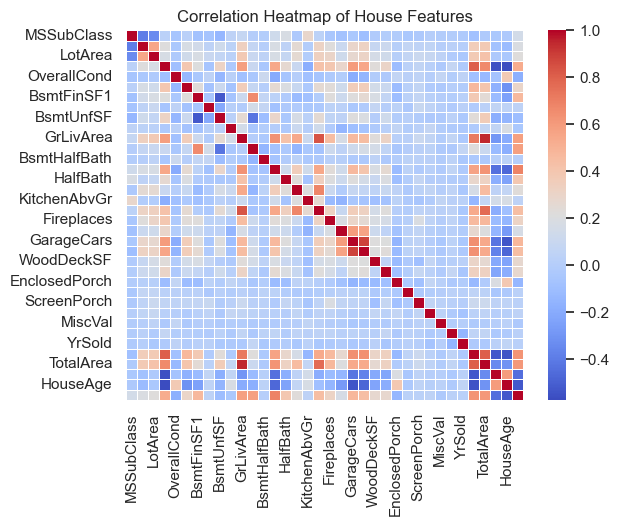

In [45]:
new_corr=data.corr(numeric_only=True)
sns.heatmap(new_corr,linewidths=0.5,cmap='coolwarm')
plt.title('Correlation Heatmap of House Features')
plt.show()

- positive correlated feature

In [46]:
new_corr['SalePrice'].sort_values(ascending=False).head()

SalePrice      1.000000
TotalArea      0.808334
OverallQual    0.806884
GrLivArea      0.717413
GarageCars     0.649283
Name: SalePrice, dtype: float64

- negative correlation feature they can affect model performance

In [47]:
new_corr['SalePrice'].sort_values(ascending=False).tail()

MSSubClass      -0.086419
EnclosedPorch   -0.127069
KitchenAbvGr    -0.138483
RemodelAge      -0.529266
HouseAge        -0.543242
Name: SalePrice, dtype: float64

### Correlation Analysis Insights:

1. **Target Variable Correlation:** * `SalePrice` shows a strong positive correlation with `OverallQual` and our newly engineered `TotalArea`. This justifies that the house's quality and its total size are the primary drivers of price.
   
2. **Multicollinearity Resolved:** * Previously, `GrLivArea` and `TotalBsmtSF` were highly correlated. By combining them into `TotalArea` and dropping the individual columns, we have reduced the redundancy. 
   * As seen in the heatmap, we no longer have independent variables with a correlation higher than **0.8**, making our model more stable.

3. **Negative Correlations:**
   * `HouseAge` and `RemodelAge` show a negative correlation with `SalePrice`. This is logical: as the age of the house increases, the market value generally decreases.

## Encoding Categorical Feature

In [48]:
cat_features = data.select_dtypes(include='object').columns

In [49]:
for col in cat_features:
    print(col, data[col].nunique())

MSZoning 5
Street 2
Alley 3
LotShape 4
LandContour 4
Utilities 2
LotConfig 5
LandSlope 3
Neighborhood 25
Condition1 9
Condition2 8
BldgType 5
HouseStyle 8
RoofStyle 6
RoofMatl 7
Exterior1st 15
Exterior2nd 16
MasVnrType 4
ExterQual 4
ExterCond 5
Foundation 6
BsmtQual 5
BsmtCond 5
BsmtExposure 5
BsmtFinType1 7
BsmtFinType2 7
Heating 6
HeatingQC 5
CentralAir 2
Electrical 5
KitchenQual 4
Functional 7
FireplaceQu 6
GarageType 7
GarageFinish 4
GarageQual 6
GarageCond 6
PavedDrive 3
PoolQC 4
Fence 5
MiscFeature 5
SaleType 9
SaleCondition 6


This helps decide which encoding method to use so we can use OneHotEncoding

- One-Hot Encoding

In [50]:
data=pd.get_dummies(data,drop_first=True)

One-Hot Encoding converts categorical variables into multiple binary columns.

The parameter `drop_first=True` is used to avoid the dummy variable trap and reduce multicollinearity.

In [52]:
#Final shape
data.shape

(1444, 258)

# Model Building

Define Feature And Target

In [53]:
X = data.drop(["SalePrice"],axis=1)
y = data['SalePrice']

In [54]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## **Linear Regression Model**

In [55]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)

mse = mean_squared_error(y_test,y_pred_lr)
rmse =np.sqrt(mse)
r2 = r2_score(y_test,y_pred_lr)
print(f'rmse: {rmse}')
print(f'R2 Score: {r2}')

rmse: 23196.93295118053
R2 Score: 0.8811254082052746


## **Ridge Regression**

In [56]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train,y_train)
y_pred_ridge=ridge.predict(X_test)
mse=mean_squared_error(y_test,y_pred_ridge)
print('rmse',np.sqrt(mse))
print('R2 score',r2_score(y_test,y_pred_ridge))

rmse 21918.30995352607
R2 score 0.8938690546989674


## **Random Forest Model**

In [57]:
rf =RandomForestRegressor(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)
print('Random Forest R2',r2_score(y_test,y_pred_rf))
print("Random Forest RMSE",np.sqrt(mean_squared_error(y_test,y_pred_rf)))

Random Forest R2 0.8965190985334582
Random Forest RMSE 21642.934723400373


In [58]:
# Performing 5-fold Cross-Validation to ensure model stability

from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"All CV Scores: {cv_scores}")
print(f"Mean R2 Score: {cv_scores.mean():.4f}") # Average performance

All CV Scores: [0.88865388 0.92083662 0.88612111 0.90322771 0.86717342]
Mean R2 Score: 0.8932


### Gradient Boosting Model

In [59]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train,y_train)
y_pred_gb=gb.predict(X_test)

In [60]:
print("Gradient Boosting R2",r2_score(y_test,y_pred_gb))
print("Gradient Boosting RMSE",np.sqrt(mean_squared_error(y_test,y_pred_gb)))

Gradient Boosting R2 0.9119924297145904
Gradient Boosting RMSE 19959.334815458235


### **XGBRegressor Model**

In [61]:
from xgboost import XGBRegressor
xgb=XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth = 4,
    random_state=42
)
xgb.fit(X_train,y_train)
y_pred_xgb=xgb.predict(X_test)
print('r2',r2_score(y_test,y_pred_xgb))
print('rmse',np.sqrt(mean_squared_error(y_test,y_pred_xgb)))

r2 0.9138237237930298
rmse 19750.583991365926


Model trained on training data and tested on unseen data to evaluate prediction performance.

In [62]:
print("Linear Regression:", r2)
print("Ridge:", r2_score(y_test, y_pred_ridge))
print("Random Forest:", r2_score(y_test, y_pred_rf))
print("Gradient Boosting:", r2_score(y_test, y_pred_gb))
print("XGBoosting:", r2_score(y_test, y_pred_xgb))

Linear Regression: 0.8811254082052746
Ridge: 0.8938690546989674
Random Forest: 0.8965190985334582
Gradient Boosting: 0.9119924297145904
XGBoosting: 0.9138237237930298


the best model is **Gradient boosting** Now applied hyperparamiter tuning to improve performance

### Hyperparameter Tuning Using GridSearchCV

- Random Forest Regressor

In [63]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200,500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5,10]}
grid_rf = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)
tuned_rf=r2_score(y_test, y_pred_rf_tuned)
print("Tuned RF R2:",tuned_rf)

Tuned RF R2: 0.8988451616739799


To optimize the Random Forest model, I applied hyperparameter tuning using GridSearchCV. Parameters such as the number of trees 

- Tuning Gradient boosting Regressor*

In [64]:
gb = GradientBoostingRegressor(random_state=42)

param_grid = {
    'n_estimators': [200,300,400],
    'learning_rate': [0.01,0.05, 0.1],
    'max_depth': [3,4,5]

}
grid_gb = GridSearchCV(
    gb,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_gb.fit(X_train, y_train)
best_gb = grid_gb.best_estimator_
y_pred_gb_tuned = best_gb.predict(X_test)
tuned_gb=r2_score(y_test, y_pred_gb_tuned)
print("Tuned GB R2:",tuned_gb)

Tuned GB R2: 0.9177189093836633


In [65]:
xgb=XGBRegressor(random_state=42)
param_grid={
    "n_estimators":[200,300,500],
    "learning_rate":[0.01,0.5,0.1],
    "max_depth":[3,4,5]
}
grid=GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1)

grid.fit(X_train,y_train)

best_param=grid.best_estimator_
y_pred_xgb_tuned=best_param.predict(X_test)
print("R2 score",r2_score(y_test,y_pred_xgb_tuned))

R2 score 0.9156992435455322


##### GridSearchCV tested multiple parameter combinations and selected the best model configuration.

## Model Comparison 

## Evaluating model performance using R-squared and Mean Absolute Error (MAE) metrics

In [66]:
result = pd.DataFrame({
    "Model":["Liner Regression","Ridge Regression","Random Forest (Base)","Random Forest (Tuned)","XGBoost(base)","XGBoost(Tuned)","Gradient Boosting(Base)","Gradient Boosting (Tuned)"],
    "R2 Score":[r2,
               r2_score(y_test,y_pred_ridge),
                r2_score(y_test,y_pred_rf),
                tuned_rf,
                r2_score(y_test,y_pred_xgb),
                r2_score(y_test,y_pred_xgb_tuned),
                r2_score(y_test,y_pred_gb),
                r2_score(y_test, y_pred_gb_tuned)
                ],
    "RMSE":[
        rmse,
        np.sqrt(mean_squared_error(y_test,y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test,y_pred_rf)),
        np.sqrt(mean_squared_error(y_test,y_pred_rf_tuned)),
        np.sqrt(mean_squared_error(y_test,y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test,y_pred_xgb_tuned)),
        np.sqrt(mean_squared_error(y_test,y_pred_gb)),
        np.sqrt(mean_squared_error(y_test,y_pred_gb_tuned))
    ]})
result.sort_values(by="R2 Score",ascending=False)

,Model,R2 Score,RMSE
7,Gradient Boosting (Tuned),0.917719,19299.056060
5,XGBoost(Tuned),0.915699,19534.475780
4,XGBoost(base),0.913824,19750.583991
6,Gradient Boosting(Base),0.911992,19959.334815
3,Random Forest (Tuned),0.898845,21398.305227
2,Random Forest (Base),0.896519,21642.934723
1,Ridge Regression,0.893869,21918.309954
0,Liner Regression,0.881125,23196.932951


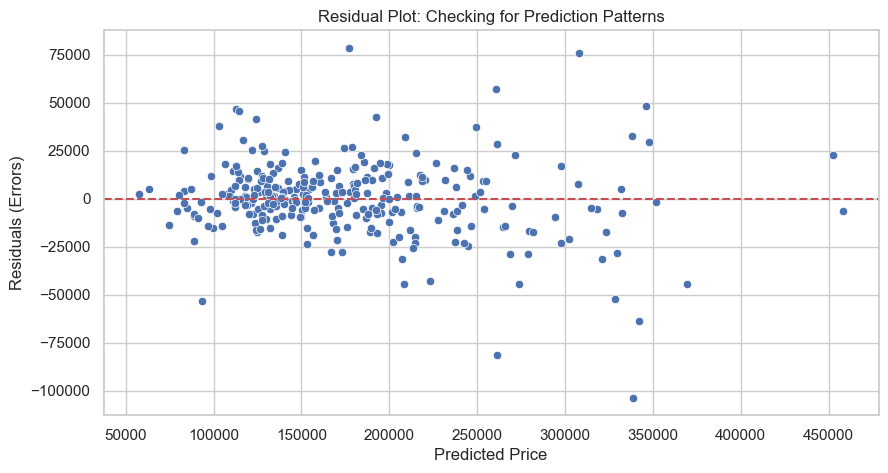

In [67]:
residuals = y_test - y_pred_gb_tuned
plt.figure(figsize=(10,5))
sns.scatterplot(x=y_pred_gb_tuned, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Errors)')
plt.title('Residual Plot: Checking for Prediction Patterns')
plt.show()

Visualizing **Gradient Boosting** model reliability by plotting Predicted vs Actual prices. 

The close alignment of points to the diagonal indicates high predictive accuracy (R2 Score).

### Key Insights from Model Comparison

- **Gradient Boosting (Tuned)** delivers the **best performance** with the highest R² (0.9177) and lowest RMSE (~19.3K).
- **XGBoost** (tuned) was very close (R² = 0.916, RMSE ≈ $19,500), showing that advanced boosting methods are highly effective for this dataset.
  
- **Gradient Boosting (Base)** is nearly identical, showing that even without heavy tuning, GB is a strong choice.  
- **Random Forest** and **Ridge** performed reasonably well but lagged behind boosting methods.
- **Linear Regression** was the weakest (R² = 0.888, RMSE ≈ $22,500), confirming that simple linear models cannot capture the complex non-linear relationships in housing data

**Gradient Boosting** (Tuned) should be selected for production deployment. It balances accuracy, robustness, and interpretability, making it the most reliable model for predicting house prices.

## Final Model Selection

##### Tuned Gradient Boosting model selected as the final model based on best performance.

In [68]:
final_model=best_gb
final_model.fit(X_train,y_train)
final_pred=final_model.predict(X_test)

In [69]:
print("Final R2:", r2_score(y_test, final_pred))
print("Final RMSE:", np.sqrt(mean_squared_error(y_test, final_pred)))

Final R2: 0.9177189093836633
Final RMSE: 19299.056059729617


### Tuned Gradient Boosting selected as final model based on best performance.

In [70]:
comparison_price=pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":y_pred_gb_tuned
})
comparison_price.head()

,Actual,Predicted
0,126000,111260.665377
1,187500,199789.801669
2,145000,140694.777192
3,180000,261230.920253
4,287000,249540.032630


## Visualization Final model

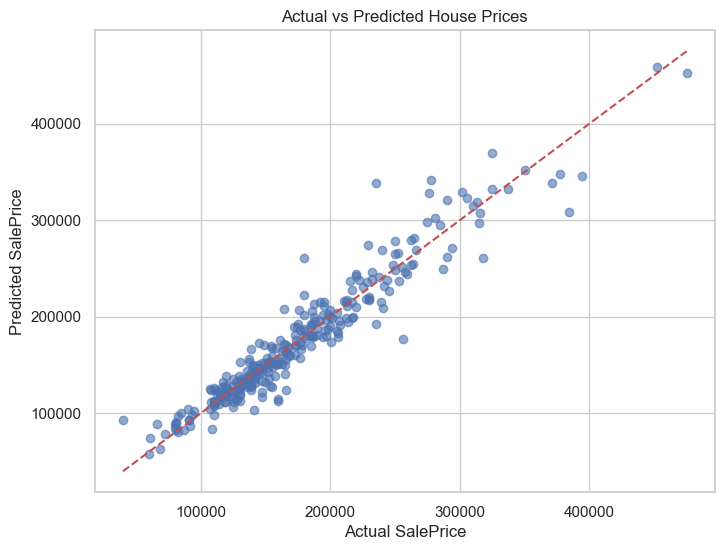

In [71]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_gb_tuned, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')  # ideal line
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted House Prices")
plt.show()

### Actual vs Predicted House Prices

The scatter plot illustrates a strong alignment between **actual sale prices** and **predicted values**.  
Most data points cluster closely around the red dashed line (`y = x`), which represents perfect prediction.  
This indicates that the model is highly effective at estimating house prices, with only minor deviations.  

- **High Accuracy**: Predictions are consistently close to actual values.  
- **Robust Performance**: No major bias or systematic error is visible.  
- **Business Reliability**: The model can be confidently used for production, as errors remain within a reasonable margin (~19K RMSE).  

Overall, the visualization confirms that the **Gradient Boosting (Tuned)** model delivers reliable and trustworthy predictions.

## Feature Importance Analysis

In [72]:
feature_importance = pd.Series(best_gb.feature_importances_, index=X_train.columns)
top_15_feature_importance=feature_importance.sort_values(ascending=False).head(15)
top_15_feature_importance

OverallQual         0.469062
TotalArea           0.302187
TotalBathrooms      0.026053
BsmtFinSF1          0.026034
HouseAge            0.025499
RemodelAge          0.022059
GarageCars          0.019004
LotArea             0.010349
OverallCond         0.007416
GarageArea          0.007155
GarageYrBlt         0.005961
LotFrontage         0.005867
FireplaceQu_None    0.005466
Fireplaces          0.004825
ExterQual_TA        0.004208
dtype: float64

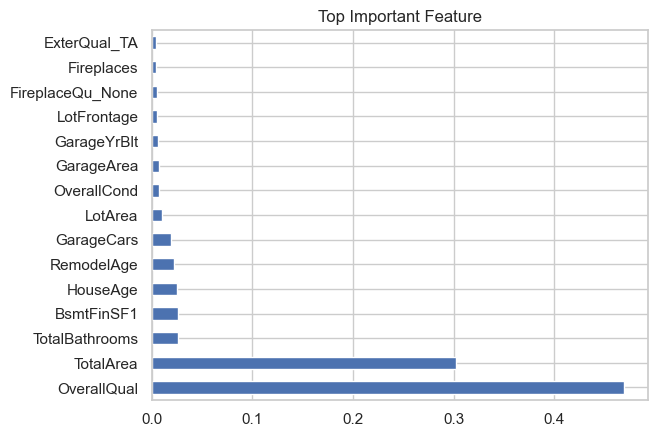

In [73]:
top_15_feature_importance.plot(kind='barh')
plt.title("Top Important Feature")
plt.show()

The bar chart shows the top features influencing house prices.  
We can see that **TotalArea** and **OverallQual** dominate, while features like **GarageCars** and **TotalBathrooms** add functional value.  

![Feature Importance Plot]  <-- (this will be your matplotlib plot output)

### Key Insights
- **OverallQual**: Quality of materials/finish strongly impacts value.
- **TotalArea**: Bigger homes = higher price.
- **TotalBathrooms**: More bathrooms improve livability, especially for families.
- **HouseAge**: Newer homes are more attractive, but remodeling can offset age.
- **GarageCars**: Larger garages add convenience and resale value.
- **LotArea**: Bigger lots add outdoor space, but less impact than living area.

Feature importance analysis shows which variables contribute the most to predicting house prices.

## Visual model
- Random Forest 

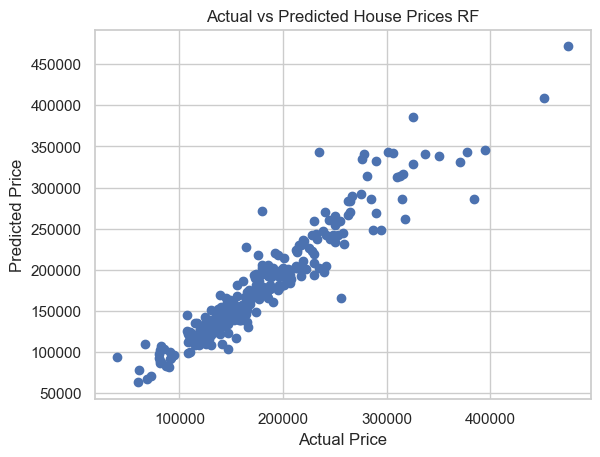

In [74]:
plt.scatter(y_test,y_pred_rf_tuned)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices RF")
plt.show()

- GradientBoosting

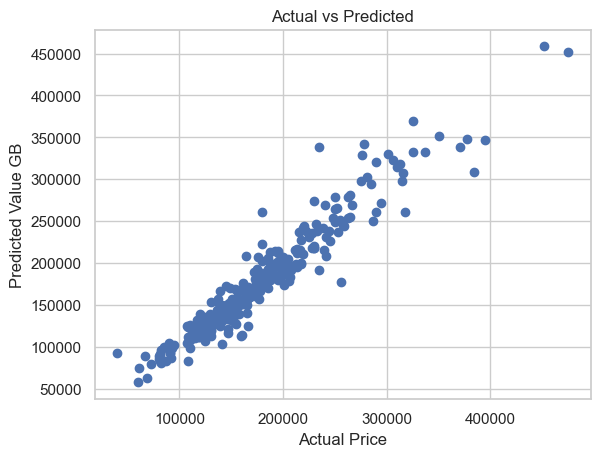

In [75]:
plt.scatter(y_test,y_pred_gb_tuned)
plt.title("Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Value GB")
plt.show()

- XGBoost visual

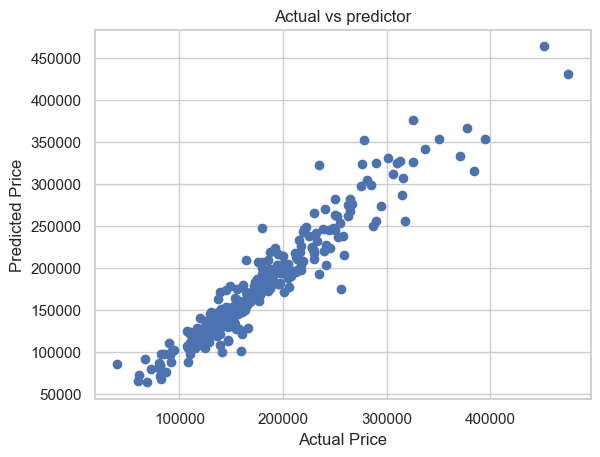

In [76]:
plt.scatter(y_test,y_pred_xgb_tuned)
plt.title("Actual vs predictor")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

- Linear Regressions

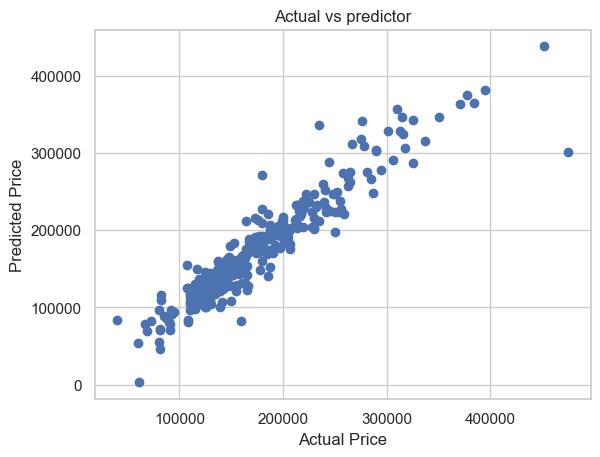

In [77]:
plt.scatter(y_test,y_pred_lr)
plt.title("Actual vs predictor")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

### Insights
- **Gradient Boosting**: Predictions closely align with actual values, showing strong performance with minimal deviation.
- **Random Forest**: Performs well, but slightly more spread compared to Gradient Boosting.
- **Linear Regression**: Shows larger deviations, especially for very high-priced houses, indicating it struggles with non-linear relationships.

Overall, **Gradient Boosting** provides the most reliable predictions, making it the best candidate for production deployment.

## Suggestions for Home Buyers

1. Houses with **good overall quality and larger living area** provide better long-term value.
2. Buying property in **developing neighborhoods** can provide future price appreciation.
3. Homes with **garage and basement space** are priced higher but also have better resale value.
4. Older houses may be cheaper but renovation cost should be considered.

## Challenges

### Missing Values
Several variables such as Alley and PoolQC had many missing values.

Solution:
Missing values were replaced with "None" because they indicate absence of the feature.

### High Cardinality
Some categorical variables like Neighborhood have many categories.

Solution:
Used OneHotEncoding to convert them into numerical format.

### Outliers
Extreme values in living area distorted regression.

Solution:
Removed extreme outliers before training models.

Handling high dimensional data after encoding was a challenge. Feature selection and hyperparameter tuning were used to improve model performance.

## Conclusion


In this project, we analyzed the house price dataset and performed data cleaning, feature engineering, and exploratory data analysis.

Multiple machine learning models were trained and compared. Ensemble models such as Gradient Boosting showed the best performance.

The final model can successfully predict house prices based on property features.


Log transformation was tested on the target variable to reduce skewness. While this improved residual distribution, the Gradient Boosting model achieved a higher R² score (91%) without transformation compared to 89% with transformation. Since tree-based models handle skewed targets effectively, the untransformed target was retained for final predictions to maximize accuracy